In [144]:
%matplotlib widget

import os
import sys
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RectangleSelector
from windrose import WindroseAxes

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)
    
from utils.paths import ICOS_CITIES_LEVEL_1, PIPELINE_DATA_DIRECTORY
from utils.os_functions import ensure_data_dir

assert (os.path.exists(ICOS_CITIES_LEVEL_1))
assert (os.path.exists(PIPELINE_DATA_DIRECTORY))

In [157]:
def annotate_month(
    df: pl.DataFrame,
    flag: np.ndarray,
    year: int,
    month: int,
    time_col="#Datetime",
    value_col="co2",
    ws_col="ws",
    wd_col="wd",
    # independent settings
    ws_min=None,                 # e.g. 0.5
    ws_max=2.0,                  # e.g. 2.0
    wd_ranges=((330, 30),),      # wrap-around supported
    # shading config
    shade_ws=True,
    shade_wd=True,
    ws_span_alpha=0.12,
    wd_span_alpha=0.12,
    ws_span_color="tab:blue",
    wd_span_color="tab:orange",
):
    def wd_mask_np(wd_deg: np.ndarray, ranges):
        wd = np.mod(wd_deg, 360.0)
        finite = np.isfinite(wd)
        out = np.zeros_like(wd, dtype=bool)
        for lo, hi in ranges:
            lo, hi = lo % 360.0, hi % 360.0
            if lo <= hi:
                out |= finite & (wd >= lo) & (wd <= hi)
            else:
                out |= finite & ((wd >= lo) | (wd <= hi))
        return out

    def ws_mask_np(ws: np.ndarray, ws_min=None, ws_max=None):
        out = np.isfinite(ws)
        if ws_min is not None:
            out &= (ws >= ws_min)
        if ws_max is not None:
            out &= (ws <= ws_max)
        return out

    def contiguous_true_spans(t_np, mask_np):
        mask_np = np.asarray(mask_np, dtype=bool)
        idx = np.flatnonzero(mask_np)
        if idx.size == 0:
            return []
        breaks = np.where(np.diff(idx) > 1)[0]
        starts = np.r_[idx[0], idx[breaks + 1]]
        ends   = np.r_[idx[breaks], idx[-1]]
        return [(t_np[s], t_np[e]) for s, e in zip(starts, ends)]

    sub = (
        df.filter(
            (pl.col(time_col).dt.year() == year) &
            (pl.col(time_col).dt.month() == month)
        )
        .select(["row_id", time_col, value_col, ws_col, wd_col])
    )

    row_id  = sub["row_id"].to_numpy()
    time_np = sub[time_col].to_numpy()
    val_np  = sub[value_col].to_numpy()

    ws = np.asarray(sub[ws_col].to_numpy(), dtype=float)  # null-safe -> nan
    wd = np.asarray(sub[wd_col].to_numpy(), dtype=float)  # null-safe -> nan

    # Independent masks
    mask_ws = ws_mask_np(ws, ws_min=ws_min, ws_max=ws_max)
    mask_wd = wd_mask_np(wd, wd_ranges)

    # Main scatter colored by GLOBAL flag
    c = flag[row_id]
    fig, ax = plt.subplots(figsize=(12, 5))
    sc = ax.scatter(time_np, val_np, c=c, cmap="coolwarm", vmin=0, vmax=1, s=25)

    ax.set_title(f"Annotate {year}-{month:02d} (rectangle flags points)")
    ax.set_xlabel("Time")
    ax.set_ylabel(value_col)
    ax.set_xlim(time_np.min(), time_np.max())

    # Shade WS spans
    if shade_ws:
        for t0, t1 in contiguous_true_spans(time_np, mask_ws):
            ax.axvspan(t0, t1, alpha=ws_span_alpha, color=ws_span_color, lw=0)

    # Shade WD spans
    if shade_wd:
        for t0, t1 in contiguous_true_spans(time_np, mask_wd):
            ax.axvspan(t0, t1, alpha=wd_span_alpha, color=wd_span_color, lw=0)

    # Legend proxies (so spans appear in legend)
    handles = []
    labels = []
    if shade_ws:
        handles.append(plt.Line2D([0], [0], color=ws_span_color, lw=8, alpha=ws_span_alpha))
        labels.append("WS condition")
    if shade_wd:
        handles.append(plt.Line2D([0], [0], color=wd_span_color, lw=8, alpha=wd_span_alpha))
        labels.append("WD condition")
    if handles:
        ax.legend(handles, labels, loc="upper right", frameon=True)

    # Rectangle selector (manual flagging)
    def on_select(eclick, erelease):
        x0, x1 = eclick.xdata, erelease.xdata
        y0, y1 = eclick.ydata, erelease.ydata
        if x0 is None or x1 is None or y0 is None or y1 is None:
            return

        t0 = np.datetime64(mdates.num2date(x0).replace(tzinfo=None), "us")
        t1 = np.datetime64(mdates.num2date(x1).replace(tzinfo=None), "us")
        tmin, tmax = sorted([t0, t1])
        ymin, ymax = sorted([y0, y1])

        sel = (time_np >= tmin) & (time_np <= tmax) & (val_np >= ymin) & (val_np <= ymax)

        flag[row_id[sel]] = 1
        sc.set_array(flag[row_id])
        fig.canvas.draw_idle()

    rect = RectangleSelector(ax, on_select, useblit=False, button=[1], interactive=True)
    fig._rect_selector = rect  # keep alive

    plt.show()

In [146]:
sites_lookup = {}
# load csv files
L1_filenames = glob.glob(os.path.join(ICOS_CITIES_LEVEL_1, '*.csv'))

for path in L1_filenames:  
    site = os.path.basename(path).split('_')[0]
    # add to dict
    sites_lookup[site] = path

# print available keys
print(sites_lookup.keys())

dict_keys(['BALR', 'HARR', 'RDIR', 'MAIR', 'PASR', 'GROR', 'BOGR', 'FELR', 'BLUT', 'TAUR', 'DLRR', 'NPLR', 'SENR', 'SCHR', 'SWMR', 'MAIR2', 'TUMR', 'FINR'])


In [174]:
# Manually select site to work on
site = 'BALR'

df = pl.read_csv(sites_lookup[site], skip_rows=44, has_header=True, separator=';', try_parse_dates=True)

# Ensure it's Polars Datetime (us) and add stable row id
df_site = df.with_row_index("row_id").with_columns(pl.col("#Datetime").cast(pl.Datetime("us"))).filter(pl.col("Flag") == "U")

# Global flags for the FULL df (persist across months)
flag = np.zeros(df.height, dtype=np.int8)

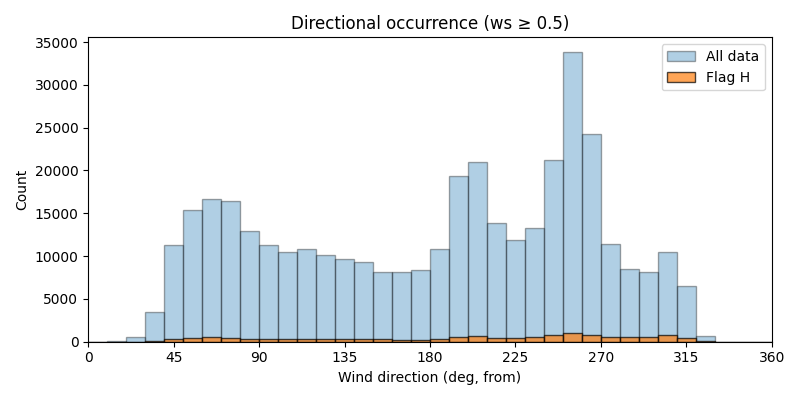

In [175]:
plot_direction_overlay(df, flag_value="H", ws_min=0.5, bin_width=10)

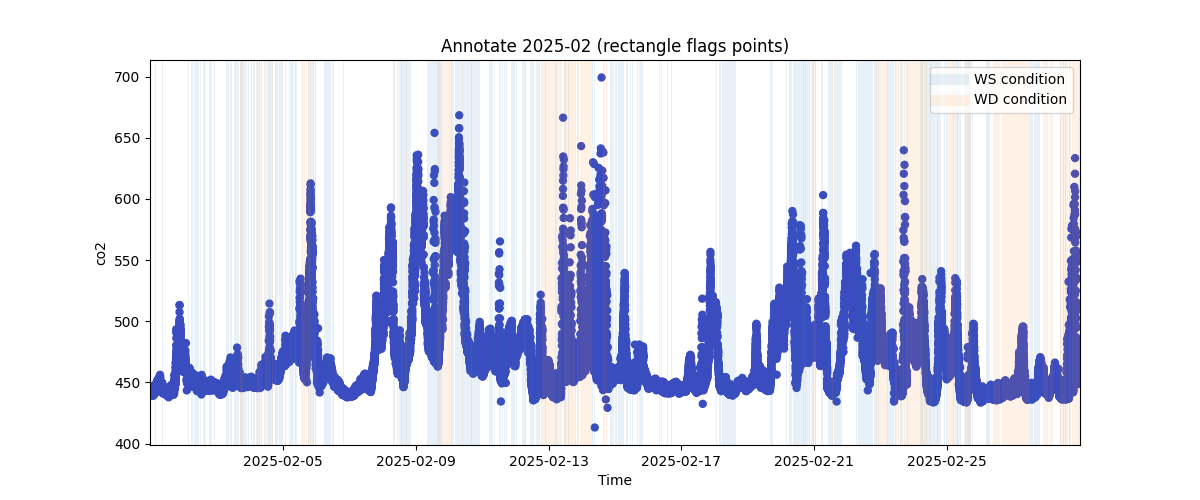

In [179]:
annotate_month(
    df_site, flag, 2025, 2,
    ws_min=0, ws_max=1.0,
    wd_ranges=((220,320),),
    ws_span_color="tab:blue",
    wd_span_color="tab:orange",
    ws_span_alpha=0.10,
    wd_span_alpha=0.10,
)

In [ ]:
# Add Manual_Flag column to original df
df_flagged = df.with_columns(pl.Series("Manual_Flag", flag))

# Percentage of flagged points
print("Percentage of flagged points:", 100 * df_flagged.get_column("Manual_Flag").sum() / df_flagged.height, "%")
df_flagged.filter(pl.col("Manual_Flag") != 0).tail()

Percentage of flagged points: 0.0 %


#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag,Manual_Flag
datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,i8


In [ ]:
output_path = os.path.join(PIPELINE_DATA_DIRECTORY, "manual_flagging")
ensure_data_dir(output_path)
df_flagged.write_parquet(f"{output_path}/{site}_manually_flagged.parquet")